# 04 — Conclusiones y análisis final de candidatas EGFR

En este notebook se analiza el conjunto final de **30 moléculas candidatas** seleccionadas como posibles inhibidores de EGFR tras el proceso de generación, filtrado y priorización computacional.

Cada molécula está representada mediante su estructura en formato **SMILES** y acompañada de variables que permiten evaluar su interés desde distintas perspectivas: actividad predicha, calidad fisicoquímica, perfil ADMET, novedad estructural y similitud frente a inhibidores de EGFR aprobados o de referencia.

Este conjunto no debe interpretarse como una lista de fármacos validados, sino como una **shortlist computacional** de moléculas prometedoras. Su objetivo es facilitar una discusión razonada sobre qué candidatos presentan un mejor equilibrio entre potencia estimada, propiedades drug-like, seguridad preliminar y originalidad estructural.

Las variables principales se agrupan en los siguientes bloques:

- **Actividad predicha frente a EGFR:** estimada mediante `predicted_pIC50`, junto con variables derivadas como `score_activity`, `predicted_active` y `predicted_strong_active`.
- **Propiedades fisicoquímicas:** incluyen `qed`, `ro5_violations`, `mol_wt`, `rdkit_logp`, `tpsa`, `hbd`, `hba` y `rot_bonds`, utilizadas para valorar la plausibilidad farmacológica de cada molécula.
- **Perfil ADMET:** resumido mediante `admet_score`, `admet_hard_pass_fraction` y filtros específicos relacionados con toxicidad, absorción, biodisponibilidad y alertas estructurales.
- **Novedad estructural:** evaluada con `max_tanimoto_training`, que mide la similitud máxima frente al conjunto de entrenamiento.
- **Relación con inhibidores EGFR conocidos:** evaluada mediante `max_tanimoto_approved_egfr`, `nearest_approved_egfr_name` y `approved_egfr_similarity_category`.

El análisis de estas 30 candidatas permitirá identificar no solo las moléculas con mayor score global, sino también aquellas que ofrecen perfiles diferenciados: candidatas más potentes, más novedosas, más equilibradas, más similares a fármacos conocidos o con mejores propiedades ADMET.


## 1. Configuración inicial y rutas del proyecto

El archivo principal de este notebook es `shortlist30_final_candidates.csv`, ya que contiene las 30 candidatas finales priorizadas.


In [8]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

SEED = 42
np.random.seed(SEED)

# Carpeta desde la que se ejecuta el notebook.
NOTEBOOK_DIR = Path.cwd().resolve()

# Raíz del proyecto. Si el notebook está dentro de notebooks/, subimos un nivel.
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebooks" else NOTEBOOK_DIR

# Carpeta raíz de los resultados del notebook 03.
SCORING_DIR = PROJECT_ROOT / "outputs" / "scoring"

# Carpeta con los resultados finales del scoring.
SCORING_FINAL_DIR = SCORING_DIR / "final"

# Carpeta con resultados intermedios útiles para auditoría.
SCORING_INTERMEDIATE_DIR = SCORING_DIR / "intermediate"

# Carpeta con resúmenes de ejecución del notebook 03.
SCORING_REPORTS_DIR = SCORING_DIR / "reports"

# CSV principal con las 30 candidatas finales.
SHORTLIST30_PATH = SCORING_FINAL_DIR / "shortlist30_final_candidates.csv"

# CSV con las moléculas del frente de Pareto.
PARETO_PATH = SCORING_INTERMEDIATE_DIR / "07_pareto_candidates.csv"

# CSV con moléculas elegibles tras criterios mínimos.
ELIGIBLE_PATH = SCORING_INTERMEDIATE_DIR / "06_eligible_candidates.csv"

# CSV completo con scores integrados, usado solo si se necesita contexto global.
SCORED_PATH = SCORING_INTERMEDIATE_DIR / "05_generated_molecules_scored.csv"

# Resumen JSON de la ejecución del notebook 03.
SCORING_SUMMARY_JSON_PATH = SCORING_REPORTS_DIR / "scoring_summary.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SHORTLIST30_PATH:", SHORTLIST30_PATH)
print("PARETO_PATH:", PARETO_PATH)
print("ELIGIBLE_PATH:", ELIGIBLE_PATH)


PROJECT_ROOT: /home/kluna/TFM-EGFR-ETL
SHORTLIST30_PATH: /home/kluna/TFM-EGFR-ETL/outputs/scoring/final/shortlist30_final_candidates.csv
PARETO_PATH: /home/kluna/TFM-EGFR-ETL/outputs/scoring/intermediate/07_pareto_candidates.csv
ELIGIBLE_PATH: /home/kluna/TFM-EGFR-ETL/outputs/scoring/intermediate/06_eligible_candidates.csv


## 2. Carga de resultados

Se cargan los archivos generados previamente. El notebook está preparado para funcionar aunque alguno de los archivos secundarios no exista, pero el `shortlist30` sí es imprescindible.


In [9]:
shortlist = pd.read_csv(SHORTLIST30_PATH)
pareto = pd.read_csv(PARETO_PATH)
eligible = pd.read_csv(ELIGIBLE_PATH)
scored = pd.read_csv(SCORED_PATH)

if SCORING_SUMMARY_JSON_PATH.exists():
    with open(SCORING_SUMMARY_JSON_PATH, "r", encoding="utf-8") as f:
        scoring_summary = json.load(f)
else:
    scoring_summary = {}

print("Shortlist30:", shortlist.shape)
print("Pareto:", pareto.shape)
print("Elegibles:", eligible.shape)
print("Scored completo:", scored.shape)


Shortlist30: (30, 45)
Pareto: (37, 144)
Elegibles: (2133, 144)
Scored completo: (8241, 144)


A partir del conjunto final de 30 candidatas es posible realizar distintos análisis para interpretar el valor farmacológico de las moléculas generadas. El objetivo no es únicamente ordenar las moléculas por un score global, sino entender qué tipo de candidato representa cada una.

En este apartado se exploran cinco dimensiones principales:

1. **Ranking global:** identificación de las moléculas mejor posicionadas según `reward_score`.
2. **Actividad predicha:** selección de candidatas con mayor `predicted_pIC50`.
3. **Perfil ADMET:** análisis de moléculas con mejor comportamiento en los filtros duros ADMET.
4. **Novedad estructural:** evaluación de la distancia frente al conjunto de entrenamiento mediante `max_tanimoto_training`.
5. **Equilibrio global:** búsqueda de moléculas que combinan actividad, calidad química, ADMET y novedad.

Este enfoque permite evitar una selección simplista basada únicamente en potencia predicha. En descubrimiento de fármacos, una molécula muy activa pero con mala seguridad, baja novedad o propiedades fisicoquímicas pobres puede ser menos interesante que otra con actividad moderada pero mejor equilibrio global.

## 3. Análisis

Antes de extraer conclusiones, conviene comprobar qué información contiene el CSV final. Para la memoria no interesa mostrar todas las columnas, sino una tabla compacta con las variables que justifican la selección: actividad, score final, ADMET, novedad estructural y propiedades fisicoquímicas.


In [10]:
df_top30 = shortlist.copy()

# Columnas compactas para visualizar el top 30 en la memoria.
summary_cols = [
    "rank", "smiles", "predicted_pIC50", "reward_score",
    "admet_hard_pass_fraction", "admet_score", "failed_admet_rules", "n_failed_admet_rules",
    "max_tanimoto_training", "training_similarity_bin",
    "max_tanimoto_approved_egfr", "nearest_approved_egfr_name",
    "qed", "ro5_violations", "mol_wt", "rdkit_logp", "tpsa", "murcko_scaffold",
]

summary_cols = [c for c in summary_cols if c in shortlist.columns]
df_top30[summary_cols].head(10)


,smiles,predicted_pIC50,reward_score,admet_hard_pass_fraction,admet_score,max_tanimoto_training,max_tanimoto_approved_egfr,nearest_approved_egfr_name,qed,ro5_violations,mol_wt,rdkit_logp,tpsa,murcko_scaffold
0,COc1ccc2ncnc(Nc3cccc(Cl)c3F)c2c1,7.678820,0.813901,0.777778,0.339286,0.603774,0.355263,gefitinib,0.788442,0,303.724,4.17450,47.04,c1ccc(Nc2ncnc3ccccc23)cc1
1,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)C1CCOCC1,7.447770,0.792513,0.888889,0.339286,0.698413,0.354839,afatinib,0.641418,0,427.302,4.50100,76.14,O=C(Nc1ccc2ncnc(Nc3ccccc3)c2c1)C1CCOCC1
2,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC1CC2(COC2)C1,7.360564,0.776262,0.888889,0.339286,0.706897,0.594595,gefitinib,0.649353,0,415.852,4.73230,65.50,c1ccc(Nc2ncnc3ccc(OC4CC5(COC5)C4)cc23)cc1
3,O=C(Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1)Nc1nc2n(n1)CCCC2,7.768092,0.767045,0.888889,0.339286,0.557143,0.290000,dacomitinib,0.401990,0,480.330,4.10270,122.54,O=C(Nc1cc2c(Nc3ccccc3)ncnc2cn1)Nc1nc2n(n1)CCCC2
4,C=CC(=O)Nc1cc(Nc2ncc(C)cn2)c(OC)cc1N1CCOCC1,7.182763,0.756761,0.888889,0.339286,0.613333,0.534884,lazertinib,0.756415,0,369.425,2.49832,88.61,c1cnc(Nc2ccc(N3CCOCC3)cc2)nc1
5,CC(C)n1cnc2ncnc(Nc3cccc(CO)c3)c21,6.852217,0.703727,1.000000,0.339286,0.365079,0.281690,erlotinib,0.769510,0,283.335,2.64310,75.86,c1ccc(Nc2ncnc3nc[nH]c23)cc1
6,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCC1,8.170641,0.701087,0.777778,0.339286,0.861111,0.861111,dacomitinib,0.443757,1,469.948,5.15510,79.38,O=C(/C=C/CN1CCCC1)Nc1ccc2ncnc(Nc3ccccc3)c2c1
7,COc1cc2ncnc(Nc3cc(F)ccc3F)c2cc1OC,6.930272,0.701011,0.777778,0.339286,0.733333,0.455882,gefitinib,0.795479,0,317.295,3.66880,56.27,c1ccc(Nc2ncnc3ccccc23)cc1
8,CC(=O)NC1CCN(C(=O)C23CC(CN2c2ncnc4cc(Cl)ccc24)C3)CC1,6.779645,0.690375,1.000000,0.339286,0.329670,0.240000,dacomitinib,0.835345,0,413.909,2.37910,78.43,O=C(N1CCCCC1)C12CC(CN1c1ncnc3ccccc13)C2
9,CC(=O)N1CCC(C(=O)Nc2cc(Nc3ccc(F)c(Cl)c3)ncn2)CC1,6.782786,0.688581,0.888889,0.339286,0.520548,0.380952,dacomitinib,0.835187,0,391.834,3.20970,87.22,O=C(Nc1cc(Nc2ccccc2)ncn1)C1CCNCC1


### 2.1 Ranking global por score final

El `reward_score` resume el criterio de priorización utilizado en el pipeline. Este score integra distintas dimensiones, como actividad predicha, perfil ADMET, similitud estructural, QED y cumplimiento de reglas fisicoquímicas.

Las moléculas con mayor `reward_score` representan las candidatas más equilibradas según los pesos definidos en el proceso de selección.

In [11]:
# Top 10 según el score global de priorización.
top_by_reward = (
    df_top30
    .sort_values("reward_score", ascending=False)
    .head(10)
)

top_by_reward[summary_cols]

,smiles,predicted_pIC50,reward_score,admet_hard_pass_fraction,admet_score,max_tanimoto_training,max_tanimoto_approved_egfr,nearest_approved_egfr_name,qed,ro5_violations,mol_wt,rdkit_logp,tpsa,murcko_scaffold
0,COc1ccc2ncnc(Nc3cccc(Cl)c3F)c2c1,7.678820,0.813901,0.777778,0.339286,0.603774,0.355263,gefitinib,0.788442,0,303.724,4.17450,47.04,c1ccc(Nc2ncnc3ccccc23)cc1
1,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)C1CCOCC1,7.447770,0.792513,0.888889,0.339286,0.698413,0.354839,afatinib,0.641418,0,427.302,4.50100,76.14,O=C(Nc1ccc2ncnc(Nc3ccccc3)c2c1)C1CCOCC1
2,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC1CC2(COC2)C1,7.360564,0.776262,0.888889,0.339286,0.706897,0.594595,gefitinib,0.649353,0,415.852,4.73230,65.50,c1ccc(Nc2ncnc3ccc(OC4CC5(COC5)C4)cc23)cc1
3,O=C(Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1)Nc1nc2n(n1)CCCC2,7.768092,0.767045,0.888889,0.339286,0.557143,0.290000,dacomitinib,0.401990,0,480.330,4.10270,122.54,O=C(Nc1cc2c(Nc3ccccc3)ncnc2cn1)Nc1nc2n(n1)CCCC2
4,C=CC(=O)Nc1cc(Nc2ncc(C)cn2)c(OC)cc1N1CCOCC1,7.182763,0.756761,0.888889,0.339286,0.613333,0.534884,lazertinib,0.756415,0,369.425,2.49832,88.61,c1cnc(Nc2ccc(N3CCOCC3)cc2)nc1
5,CC(C)n1cnc2ncnc(Nc3cccc(CO)c3)c21,6.852217,0.703727,1.000000,0.339286,0.365079,0.281690,erlotinib,0.769510,0,283.335,2.64310,75.86,c1ccc(Nc2ncnc3nc[nH]c23)cc1
6,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCC1,8.170641,0.701087,0.777778,0.339286,0.861111,0.861111,dacomitinib,0.443757,1,469.948,5.15510,79.38,O=C(/C=C/CN1CCCC1)Nc1ccc2ncnc(Nc3ccccc3)c2c1
7,COc1cc2ncnc(Nc3cc(F)ccc3F)c2cc1OC,6.930272,0.701011,0.777778,0.339286,0.733333,0.455882,gefitinib,0.795479,0,317.295,3.66880,56.27,c1ccc(Nc2ncnc3ccccc23)cc1
8,CC(=O)NC1CCN(C(=O)C23CC(CN2c2ncnc4cc(Cl)ccc24)C3)CC1,6.779645,0.690375,1.000000,0.339286,0.329670,0.240000,dacomitinib,0.835345,0,413.909,2.37910,78.43,O=C(N1CCCCC1)C12CC(CN1c1ncnc3ccccc13)C2
9,CC(=O)N1CCC(C(=O)Nc2cc(Nc3ccc(F)c(Cl)c3)ncn2)CC1,6.782786,0.688581,0.888889,0.339286,0.520548,0.380952,dacomitinib,0.835187,0,391.834,3.20970,87.22,O=C(Nc1cc(Nc2ccccc2)ncn1)C1CCNCC1


### 2.2 Candidatas con mayor actividad predicha

La `predicted_pIC50` permite identificar las moléculas con mayor potencia estimada frente a EGFR. Valores más altos indican una menor concentración necesaria para inhibir el 50 % de la actividad, por lo que son deseables desde el punto de vista de actividad.

No obstante, estas moléculas no deben seleccionarse de forma aislada: una alta actividad predicha debe interpretarse junto con ADMET, novedad estructural y propiedades drug-like.

In [12]:
# Top 10 según actividad predicha.
top_by_activity = (
    df_top30
    .sort_values("predicted_pIC50", ascending=False)
    .head(10)
)

top_by_activity[summary_cols]

,smiles,predicted_pIC50,reward_score,admet_hard_pass_fraction,admet_score,max_tanimoto_training,max_tanimoto_approved_egfr,nearest_approved_egfr_name,qed,ro5_violations,mol_wt,rdkit_logp,tpsa,murcko_scaffold
6,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCC1,8.170641,0.701087,0.777778,0.339286,0.861111,0.861111,dacomitinib,0.443757,1,469.948,5.15510,79.38,O=C(/C=C/CN1CCCC1)Nc1ccc2ncnc(Nc3ccccc3)c2c1
3,O=C(Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1)Nc1nc2n(n1)CCCC2,7.768092,0.767045,0.888889,0.339286,0.557143,0.290000,dacomitinib,0.401990,0,480.330,4.10270,122.54,O=C(Nc1cc2c(Nc3ccccc3)ncnc2cn1)Nc1nc2n(n1)CCCC2
0,COc1ccc2ncnc(Nc3cccc(Cl)c3F)c2c1,7.678820,0.813901,0.777778,0.339286,0.603774,0.355263,gefitinib,0.788442,0,303.724,4.17450,47.04,c1ccc(Nc2ncnc3ccccc23)cc1
15,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC1CN(C(=O)OC(C)(C)C)CC1F,7.569358,0.676497,0.888889,0.339286,0.592593,0.357143,erlotinib,0.465007,2,533.398,5.48070,85.81,c1ccc(Nc2ncnc3ccc(OC4CCNC4)cc23)cc1
1,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)C1CCOCC1,7.447770,0.792513,0.888889,0.339286,0.698413,0.354839,afatinib,0.641418,0,427.302,4.50100,76.14,O=C(Nc1ccc2ncnc(Nc3ccccc3)c2c1)C1CCOCC1
2,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC1CC2(COC2)C1,7.360564,0.776262,0.888889,0.339286,0.706897,0.594595,gefitinib,0.649353,0,415.852,4.73230,65.50,c1ccc(Nc2ncnc3ccc(OC4CC5(COC5)C4)cc23)cc1
4,C=CC(=O)Nc1cc(Nc2ncc(C)cn2)c(OC)cc1N1CCOCC1,7.182763,0.756761,0.888889,0.339286,0.613333,0.534884,lazertinib,0.756415,0,369.425,2.49832,88.61,c1cnc(Nc2ccc(N3CCOCC3)cc2)nc1
26,COc1cc2ncnc(NC(c3ccccc3)c3cnccn3)c2cc1NC(=O)c1cc2c(nc1O)CCC2=O,7.158876,0.634842,0.888889,0.361960,0.470588,0.317757,dacomitinib,0.278576,1,533.548,4.11170,152.11,O=C(Nc1ccc2ncnc(NC(c3ccccc3)c3cnccn3)c2c1)c1cnc2c(c1)C(=O)CC2
21,Fc1cc2ncnc(Nc3cnn(Cc4ccncc4)c3)c2cc1Nc1cnn(C2CCC2)c1,6.966390,0.656198,0.888889,0.347838,0.416667,0.319588,dacomitinib,0.363093,0,455.501,4.81740,98.37,c1cc(Cn2cc(Nc3ncnc4ccc(Nc5cnn(C6CCC6)c5)cc34)cn2)ccn1
10,COc1ccc2c(NC(CO)C(O)c3ccc(S(C)(=O)=O)cc3)ncnc2c1,6.935125,0.686361,1.000000,0.339286,0.428571,0.237500,erlotinib,0.543195,0,403.460,1.54830,121.64,c1ccc(CCNc2ncnc3ccccc23)cc1


### 2.3 Candidatas con mejor perfil ADMET

El perfil ADMET se evaluó mediante filtros duros y un score agregado. En esta etapa interesa identificar moléculas que superen el mayor número posible de criterios relacionados con toxicidad, absorción y biodisponibilidad.

Las moléculas con `admet_hard_pass_fraction` igual a 1 superan todos los filtros ADMET duros definidos.

In [13]:
# Top 10 priorizando primero filtros ADMET duros y después reward_score.
top_by_admet = (
    df_top30
    .sort_values(
        ["admet_hard_pass_fraction", "admet_score", "reward_score"],
        ascending=[False, False, False]
    )
    .head(10)
)

top_by_admet[summary_cols]

,smiles,predicted_pIC50,reward_score,admet_hard_pass_fraction,admet_score,max_tanimoto_training,max_tanimoto_approved_egfr,nearest_approved_egfr_name,qed,ro5_violations,mol_wt,rdkit_logp,tpsa,murcko_scaffold
5,CC(C)n1cnc2ncnc(Nc3cccc(CO)c3)c21,6.852217,0.703727,1.000000,0.339286,0.365079,0.281690,erlotinib,0.769510,0,283.335,2.64310,75.86,c1ccc(Nc2ncnc3nc[nH]c23)cc1
8,CC(=O)NC1CCN(C(=O)C23CC(CN2c2ncnc4cc(Cl)ccc24)C3)CC1,6.779645,0.690375,1.000000,0.339286,0.329670,0.240000,dacomitinib,0.835345,0,413.909,2.37910,78.43,O=C(N1CCCCC1)C12CC(CN1c1ncnc3ccccc13)C2
10,COc1ccc2c(NC(CO)C(O)c3ccc(S(C)(=O)=O)cc3)ncnc2c1,6.935125,0.686361,1.000000,0.339286,0.428571,0.237500,erlotinib,0.543195,0,403.460,1.54830,121.64,c1ccc(CCNc2ncnc3ccccc23)cc1
14,CCc1ncnc(Nc2ccc(F)c(C#N)c2)c1OC,6.598890,0.676569,1.000000,0.339286,0.485294,0.316456,gefitinib,0.926227,0,272.283,2.80198,70.83,c1ccc(Nc2ccncn2)cc1
16,NC(=O)c1cc(Nc2cncc(N3CCOCC3)c2)ccn1,6.609368,0.671664,1.000000,0.339286,0.351351,0.230000,lazertinib,0.879554,0,299.334,1.15570,93.37,c1cc(Nc2cncc(N3CCOCC3)c2)ccn1
18,O=C(Nc1ccc(Br)c(F)c1F)c1cc(N2CCOCC2)ccn1,6.631773,0.665329,1.000000,0.339286,0.369231,0.235294,lazertinib,0.807446,0,398.207,3.21120,54.46,O=C(Nc1ccccc1)c1cc(N2CCOCC2)ccn1
22,CC(=O)Nc1nc(C(=O)N2CCC(c3ncco3)CC2)cs1,6.489532,0.656078,1.000000,0.339286,0.424242,0.180000,osimertinib,0.935428,0,320.374,2.10930,88.33,O=C(c1cscn1)N1CCC(c2ncco2)CC1
27,CN(CC(F)F)C(=O)Nc1ccc2c(Cl)ccnc2c1,6.250883,0.609128,1.000000,0.339286,0.371429,0.268817,afatinib,0.940626,0,299.708,3.61700,45.23,c1ccc2ncccc2c1
28,O=C(Nc1ncc(Oc2ccccc2)cn1)N1CCCC1,6.192257,0.597408,1.000000,0.339286,0.367647,0.185567,lazertinib,0.940665,0,284.319,2.89660,67.35,O=C(Nc1ncc(Oc2ccccc2)cn1)N1CCCC1
26,COc1cc2ncnc(NC(c3ccccc3)c3cnccn3)c2cc1NC(=O)c1cc2c(nc1O)CCC2=O,7.158876,0.634842,0.888889,0.361960,0.470588,0.317757,dacomitinib,0.278576,1,533.548,4.11170,152.11,O=C(Nc1ccc2ncnc(NC(c3ccccc3)c3cnccn3)c2c1)c1cnc2c(c1)C(=O)CC2


### 2.4 Candidatas más novedosas frente al conjunto de entrenamiento

La similitud máxima frente al conjunto de entrenamiento (`max_tanimoto_training`) permite detectar si una molécula es muy cercana a compuestos ya conocidos o si explora regiones más nuevas del espacio químico.

Valores bajos indican mayor novedad estructural. Sin embargo, una similitud extremadamente baja también puede implicar mayor incertidumbre en la predicción del modelo. Por ello, las moléculas más interesantes suelen estar en un equilibrio entre novedad y proximidad razonable al espacio químico aprendido.

In [14]:
# Top 10 más novedosas, evitando ordenar únicamente por baja similitud si tienen baja actividad.
top_by_novelty = (
    df_top30
    .sort_values(
        ["max_tanimoto_training", "predicted_pIC50", "reward_score"],
        ascending=[True, False, False]
    )
    .head(10)
)

top_by_novelty[summary_cols]

,smiles,predicted_pIC50,reward_score,admet_hard_pass_fraction,admet_score,max_tanimoto_training,max_tanimoto_approved_egfr,nearest_approved_egfr_name,qed,ro5_violations,mol_wt,rdkit_logp,tpsa,murcko_scaffold
23,Cc1cc(N2CCSCC2)ccc1NC(=O)/C=C/c1ccncn1,6.667808,0.644627,0.777778,0.339286,0.315789,0.231579,dacomitinib,0.867281,0,340.452,2.99012,58.12,O=C(/C=C/c1ccncn1)Nc1ccc(N2CCSCC2)cc1
20,Cc1nc(N(C)CC(C)NC(=O)C2CCN(C)C2)c2ccccc2n1,6.637261,0.659769,0.888889,0.339286,0.328358,0.227723,osimertinib,0.898969,0,341.459,1.83082,61.36,O=C(NCCNc1ncnc2ccccc12)C1CCNC1
8,CC(=O)NC1CCN(C(=O)C23CC(CN2c2ncnc4cc(Cl)ccc24)C3)CC1,6.779645,0.690375,1.000000,0.339286,0.329670,0.240000,dacomitinib,0.835345,0,413.909,2.37910,78.43,O=C(N1CCCCC1)C12CC(CN1c1ncnc3ccccc13)C2
11,CC1OCCN(C(=O)c2nccnc2Nc2ccc(N3CCN(C)CC3)cc2F)C1C,6.811856,0.683741,0.888889,0.339286,0.336957,0.201923,dacomitinib,0.801426,0,428.512,2.36050,73.83,O=C(c1nccnc1Nc1ccc(N2CCNCC2)cc1)N1CCOCC1
24,Nc1ncc(CN2CCN(c3ccc(F)c(Cl)c3)CC2)s1,6.491466,0.641094,0.888889,0.339286,0.337838,0.256098,gefitinib,0.941782,0,326.828,2.84000,45.39,c1ccc(N2CCN(Cc3cncs3)CC2)cc1
29,COc1cc(OC)cc(C(Nc2cc(N3CCOCC3)ncn2)c2ncn(C(C)C)c2C)c1,6.482153,0.588466,0.888889,0.355684,0.347222,0.210526,gefitinib,0.554666,0,452.559,3.61772,86.56,c1ccc(C(Nc2cc(N3CCOCC3)ncn2)c2c[nH]cn2)cc1
16,NC(=O)c1cc(Nc2cncc(N3CCOCC3)c2)ccn1,6.609368,0.671664,1.000000,0.339286,0.351351,0.230000,lazertinib,0.879554,0,299.334,1.15570,93.37,c1cc(Nc2cncc(N3CCOCC3)c2)ccn1
5,CC(C)n1cnc2ncnc(Nc3cccc(CO)c3)c21,6.852217,0.703727,1.000000,0.339286,0.365079,0.281690,erlotinib,0.769510,0,283.335,2.64310,75.86,c1ccc(Nc2ncnc3nc[nH]c23)cc1
28,O=C(Nc1ncc(Oc2ccccc2)cn1)N1CCCC1,6.192257,0.597408,1.000000,0.339286,0.367647,0.185567,lazertinib,0.940665,0,284.319,2.89660,67.35,O=C(Nc1ncc(Oc2ccccc2)cn1)N1CCCC1
18,O=C(Nc1ccc(Br)c(F)c1F)c1cc(N2CCOCC2)ccn1,6.631773,0.665329,1.000000,0.339286,0.369231,0.235294,lazertinib,0.807446,0,398.207,3.21120,54.46,O=C(Nc1ccccc1)c1cc(N2CCOCC2)ccn1


### 2.5 Candidatas más equilibradas

Para obtener una selección más defendible, se puede construir un ranking equilibrado combinando actividad, ADMET, QED y novedad estructural. Este ranking no sustituye al `reward_score`, pero ayuda a interpretar qué moléculas presentan un perfil global más robusto.

En este caso se favorecen moléculas con:

- alta actividad predicha;
- buen cumplimiento ADMET;
- QED elevado;
- baja o moderada similitud frente al conjunto de entrenamiento;
- ausencia de violaciones relevantes de reglas básicas.

In [15]:
df_balanced = df_top30.copy()

# Normalización sencilla min-max para variables donde "más alto es mejor".
def minmax(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series(1.0, index=series.index)
    return (series - min_val) / (max_val - min_val)

df_balanced["norm_activity"] = minmax(df_balanced["predicted_pIC50"])
df_balanced["norm_qed"] = minmax(df_balanced["qed"])
df_balanced["norm_admet_hard"] = minmax(df_balanced["admet_hard_pass_fraction"])

# Para novedad, menor similitud al entrenamiento es mejor.
# Se invierte la similitud para que valores más altos indiquen mayor novedad.
df_balanced["norm_novelty"] = 1 - minmax(df_balanced["max_tanimoto_training"])

# Penalización suave por violaciones Ro5.
# Si no hay violaciones, recibe 1. Si hay más, disminuye.
df_balanced["norm_ro5"] = 1 / (1 + df_balanced["ro5_violations"])

# Score equilibrado interpretable.
# Los pesos se pueden ajustar, pero aquí se da más importancia a actividad y ADMET.
df_balanced["balanced_score"] = (
    0.35 * df_balanced["norm_activity"] +
    0.25 * df_balanced["norm_admet_hard"] +
    0.20 * df_balanced["norm_qed"] +
    0.15 * df_balanced["norm_novelty"] +
    0.05 * df_balanced["norm_ro5"]
)

balanced_cols = [
    "rank",
    "smiles",
    "balanced_score",
    "predicted_pIC50",
    "admet_hard_pass_fraction",
    "qed",
    "max_tanimoto_training",
    "ro5_violations",
    "reward_score",
    "nearest_approved_egfr_name",
    "approved_egfr_similarity_category",
]

balanced_cols = [col for col in balanced_cols if col in df_balanced.columns]

top_balanced = (
    df_balanced
    .sort_values("balanced_score", ascending=False)
    .head(10)
)

top_balanced[balanced_cols]

,smiles,balanced_score,predicted_pIC50,admet_hard_pass_fraction,qed,max_tanimoto_training,ro5_violations,reward_score,nearest_approved_egfr_name,approved_egfr_similarity_category
8,CC(=O)NC1CCN(C(=O)C23CC(CN2c2ncnc4cc(Cl)ccc24)C3)CC1,0.717864,6.779645,1.000000,0.835345,0.329670,0,0.690375,dacomitinib,novedad alta frente a aprobados
5,CC(C)n1cnc2ncnc(Nc3cccc(CO)c3)c21,0.701126,6.852217,1.000000,0.769510,0.365079,0,0.703727,erlotinib,novedad alta frente a aprobados
16,NC(=O)c1cc(Nc2cncc(N3CCOCC3)c2)ccn1,0.695098,6.609368,1.000000,0.879554,0.351351,0,0.671664,lazertinib,novedad alta frente a aprobados
18,O=C(Nc1ccc(Br)c(F)c1F)c1cc(N2CCOCC2)ccn1,0.672415,6.631773,1.000000,0.807446,0.369231,0,0.665329,lazertinib,novedad alta frente a aprobados
22,CC(=O)Nc1nc(C(=O)N2CCC(c3ncco3)CC2)cs1,0.670683,6.489532,1.000000,0.935428,0.424242,0,0.656078,osimertinib,novedad alta frente a aprobados
14,CCc1ncnc(Nc2ccc(F)c(C#N)c2)c1OC,0.670464,6.598890,1.000000,0.926227,0.485294,0,0.676569,gefitinib,novedad alta frente a aprobados
27,CN(CC(F)F)C(=O)Nc1ccc2c(Cl)ccnc2c1,0.644557,6.250883,1.000000,0.940626,0.371429,0,0.609128,afatinib,novedad alta frente a aprobados
28,O=C(Nc1ncc(Oc2ccccc2)cn1)N1CCCC1,0.635237,6.192257,1.000000,0.940665,0.367647,0,0.597408,lazertinib,novedad alta frente a aprobados
10,COc1ccc2c(NC(CO)C(O)c3ccc(S(C)(=O)=O)cc3)ncnc2c1,0.630135,6.935125,1.000000,0.543195,0.428571,0,0.686361,erlotinib,novedad alta frente a aprobados
20,Cc1nc(N(C)CC(C)NC(=O)C2CCN(C)C2)c2ccccc2n1,0.587207,6.637261,0.888889,0.898969,0.328358,0,0.659769,osimertinib,novedad alta frente a aprobados


Este análisis permite observar que el top 30 no debe interpretarse como una única lista cerrada, sino como un conjunto de moléculas con perfiles diferentes. Algunas candidatas destacan por actividad predicha, otras por mejor perfil ADMET, otras por mayor novedad estructural y otras por equilibrio global.Para la discusión final de la memoria, resulta más sólido seleccionar un subconjunto de candidatas representativas que cubran estos perfiles, en lugar de limitarse a escoger las primeras moléculas por `reward_score`.

### 2.6 Perfiles de candidatos

Además del ranking global, se definieron perfiles representativos para interpretar mejor el conjunto final de moléculas. Esta estrategia permite identificar candidatos con fortalezas distintas: mayor actividad predicha, mejor perfil ADMET, mayor novedad estructural, mejor calidad drug-like o mejor equilibrio global.

Este análisis es útil porque una molécula no tiene que ser la mejor en todos los parámetros para ser relevante. En fases tempranas de descubrimiento, puede ser interesante conservar candidatos con perfiles complementarios.

In [16]:
df_profiles = df_balanced.copy()

candidate_profiles = []

# Mejor candidato global según el score original del pipeline.
candidate_profiles.append({
    "profile": "Mejor score global",
    "selection_criterion": "Máximo reward_score",
    "row": df_profiles.sort_values("reward_score", ascending=False).iloc[0]
})

# Candidato con mayor actividad predicha.
candidate_profiles.append({
    "profile": "Mayor actividad predicha",
    "selection_criterion": "Máxima predicted_pIC50",
    "row": df_profiles.sort_values("predicted_pIC50", ascending=False).iloc[0]
})

# Candidato con mejor perfil ADMET duro.
candidate_profiles.append({
    "profile": "Mejor perfil ADMET",
    "selection_criterion": "Máxima fracción de filtros ADMET duros superados y mayor reward_score",
    "row": df_profiles.sort_values(
        ["admet_hard_pass_fraction", "reward_score"],
        ascending=[False, False]
    ).iloc[0]
})

# Candidato más novedoso frente al entrenamiento, priorizando que mantenga actividad razonable.
candidate_profiles.append({
    "profile": "Mayor novedad estructural",
    "selection_criterion": "Menor max_tanimoto_training con pIC50 predicha aceptable",
    "row": df_profiles[df_profiles["predicted_pIC50"] >= 6.0]
        .sort_values("max_tanimoto_training", ascending=True)
        .iloc[0]
})

# Candidato con mejor calidad drug-like.
candidate_profiles.append({
    "profile": "Mejor calidad drug-like",
    "selection_criterion": "Máximo QED y ausencia de violaciones Ro5",
    "row": df_profiles.sort_values(
        ["qed", "ro5_violations", "reward_score"],
        ascending=[False, True, False]
    ).iloc[0]
})

# Candidato más equilibrado según el score interpretable creado anteriormente.
candidate_profiles.append({
    "profile": "Mejor equilibrio global",
    "selection_criterion": "Máximo balanced_score",
    "row": df_profiles.sort_values("balanced_score", ascending=False).iloc[0]
})

# Conversión de los perfiles a tabla.
profile_rows = []

for item in candidate_profiles:
    row = item["row"]
    profile_rows.append({
        "profile": item["profile"],
        "selection_criterion": item["selection_criterion"],
        "smiles": row.get("smiles", None),
        "predicted_pIC50": row.get("predicted_pIC50", None),
        "reward_score": row.get("reward_score", None),
        "balanced_score": row.get("balanced_score", None),
        "admet_hard_pass_fraction": row.get("admet_hard_pass_fraction", None),
        "qed": row.get("qed", None),
        "ro5_violations": row.get("ro5_violations", None),
        "max_tanimoto_training": row.get("max_tanimoto_training", None),
        "nearest_approved_egfr_name": row.get("nearest_approved_egfr_name", None),
        "approved_egfr_similarity_category": row.get("approved_egfr_similarity_category", None),
        "murcko_scaffold": row.get("murcko_scaffold", None),
    })

df_candidate_profiles = pd.DataFrame(profile_rows)

# Eliminamos duplicados: una misma molécula puede cumplir varios perfiles.
df_candidate_profiles_unique = (
    df_candidate_profiles
    .drop_duplicates(subset=["smiles"])
    .reset_index(drop=True)
)

df_candidate_profiles_unique

,profile,selection_criterion,smiles,predicted_pIC50,reward_score,balanced_score,admet_hard_pass_fraction,qed,ro5_violations,max_tanimoto_training,nearest_approved_egfr_name,approved_egfr_similarity_category,murcko_scaffold
0,Mejor score global,Máximo reward_score,COc1ccc2ncnc(Nc3cccc(Cl)c3F)c2c1,7.678820,0.813901,0.537409,0.777778,0.788442,0,0.603774,gefitinib,novedad alta frente a aprobados,c1ccc(Nc2ncnc3ccccc23)cc1
1,Mayor actividad predicha,Máxima predicted_pIC50,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCC1,8.170641,0.701087,0.424773,0.777778,0.443757,1,0.861111,dacomitinib,análogo cercano de aprobado,O=C(/C=C/CN1CCCC1)Nc1ccc2ncnc(Nc3ccccc3)c2c1
2,Mejor perfil ADMET,Máxima fracción de filtros ADMET duros superados y mayor reward_score,CC(C)n1cnc2ncnc(Nc3cccc(CO)c3)c21,6.852217,0.703727,0.701126,1.000000,0.769510,0,0.365079,erlotinib,novedad alta frente a aprobados,c1ccc(Nc2ncnc3nc[nH]c23)cc1
3,Mayor novedad estructural,Menor max_tanimoto_training con pIC50 predicha aceptable,Cc1cc(N2CCSCC2)ccc1NC(=O)/C=C/c1ccncn1,6.667808,0.644627,0.461520,0.777778,0.867281,0,0.315789,dacomitinib,novedad alta frente a aprobados,O=C(/C=C/c1ccncn1)Nc1ccc(N2CCSCC2)cc1
4,Mejor calidad drug-like,Máximo QED y ausencia de violaciones Ro5,COc1ccc2c(NC(=O)C3C(C)OC(C)C3C)ncnc2c1,6.502107,0.637404,0.411648,0.777778,0.942319,0,0.472727,dacomitinib,novedad alta frente a aprobados,O=C(Nc1ncnc2ccccc12)C1CCOC1
5,Mejor equilibrio global,Máximo balanced_score,CC(=O)NC1CCN(C(=O)C23CC(CN2c2ncnc4cc(Cl)ccc24)C3)CC1,6.779645,0.690375,0.717864,1.000000,0.835345,0,0.329670,dacomitinib,novedad alta frente a aprobados,O=C(N1CCCCC1)C12CC(CN1c1ncnc3ccccc13)C2


### 2.7 Análisis de scaffolds

El scaffold de Murcko representa el núcleo estructural principal de una molécula. Analizar los scaffolds permite evaluar si el top 30 contiene diversidad química real o si está dominado por una misma familia estructural.

Este análisis es importante porque una selección final compuesta por moléculas muy parecidas puede sobreestimar la diversidad del conjunto. En cambio, identificar varios scaffolds diferentes permite proponer candidatos alternativos con esqueletos químicos distintos.

In [17]:
# Frecuencia de cada scaffold en el top 30.
scaffold_counts = (
    df_top30["murcko_scaffold"]
    .value_counts()
    .reset_index()
)

scaffold_counts.columns = ["murcko_scaffold", "n_candidates"]

# Se calcula también la actividad media y el reward medio por scaffold.
scaffold_summary = (
    df_top30
    .groupby("murcko_scaffold")
    .agg(
        n_candidates=("smiles", "count"),
        mean_predicted_pIC50=("predicted_pIC50", "mean"),
        max_predicted_pIC50=("predicted_pIC50", "max"),
        mean_reward_score=("reward_score", "mean"),
        mean_qed=("qed", "mean"),
        mean_training_similarity=("max_tanimoto_training", "mean"),
        mean_admet_hard_pass_fraction=("admet_hard_pass_fraction", "mean"),
    )
    .reset_index()
    .sort_values(
        ["n_candidates", "mean_reward_score"],
        ascending=[False, False]
    )
)

scaffold_summary

,murcko_scaffold,n_candidates,mean_predicted_pIC50,max_predicted_pIC50,mean_reward_score,mean_qed,mean_training_similarity,mean_admet_hard_pass_fraction
23,c1ccc(Nc2ncnc3ccccc23)cc1,2,7.304546,7.678820,0.757456,0.791960,0.668553,0.777778
7,O=C(Nc1ccc2ncnc(Nc3ccccc3)c2c1)C1CCOCC1,1,7.447770,7.447770,0.792513,0.641418,0.698413,0.888889
21,c1ccc(Nc2ncnc3ccc(OC4CC5(COC5)C4)cc23)cc1,1,7.360564,7.360564,0.776262,0.649353,0.706897,0.888889
5,O=C(Nc1cc2c(Nc3ccccc3)ncnc2cn1)Nc1nc2n(n1)CCCC2,1,7.768092,7.768092,0.767045,0.401990,0.557143,0.888889
28,c1cnc(Nc2ccc(N3CCOCC3)cc2)nc1,1,7.182763,7.182763,0.756761,0.756415,0.613333,0.888889
24,c1ccc(Nc2ncnc3nc[nH]c23)cc1,1,6.852217,6.852217,0.703727,0.769510,0.365079,1.000000
0,O=C(/C=C/CN1CCCC1)Nc1ccc2ncnc(Nc3ccccc3)c2c1,1,8.170641,8.170641,0.701087,0.443757,0.861111,0.777778
2,O=C(N1CCCCC1)C12CC(CN1c1ncnc3ccccc13)C2,1,6.779645,6.779645,0.690375,0.835345,0.329670,1.000000
4,O=C(Nc1cc(Nc2ccccc2)ncn1)C1CCNCC1,1,6.782786,6.782786,0.688581,0.835187,0.520548,0.888889
16,c1ccc(CCNc2ncnc3ccccc23)cc1,1,6.935125,6.935125,0.686361,0.543195,0.428571,1.000000


In [18]:
# Número de scaffolds únicos en el top 30.
n_unique_scaffolds = df_top30["murcko_scaffold"].nunique()

print(f"Número de moléculas en el top 30: {len(df_top30)}")
print(f"Número de scaffolds únicos: {n_unique_scaffolds}")
print(f"Ratio de diversidad scaffold/molécula: {n_unique_scaffolds / len(df_top30):.2f}")

Número de moléculas en el top 30: 30
Número de scaffolds únicos: 29
Ratio de diversidad scaffold/molécula: 0.97


## 3. Representación visual de las candidatas seleccionadas

Una vez identificadas las 30 candidatas finales, el top 10 equilibrado y los perfiles representativos, es importante transformar los resultados tabulares en visualizaciones interpretables.

El objetivo de este apartado es facilitar la comparación entre moléculas, detectar patrones globales y seleccionar figuras útiles para la memoria. Las representaciones se centran en cuatro niveles:

1. **Distribución de propiedades clave** en el top 30.
2. **Relación entre actividad, ADMET y novedad estructural**.
3. **Visualización 2D de las moléculas seleccionadas**.
4. **Comparación de perfiles representativos de candidatos**.

Estas visualizaciones permiten justificar la selección final de forma más clara que una tabla completa de descriptores.

### 3.1 Distribución de propiedades principales en el top 30

En primer lugar, se representan las distribuciones de las variables más relevantes del top 30: actividad predicha, score global, QED, LogP, peso molecular, TPSA, similitud frente al entrenamiento y fracción de filtros ADMET superados.

Estas gráficas permiten comprobar si el conjunto final presenta valores homogéneos o si existen moléculas claramente diferenciadas.

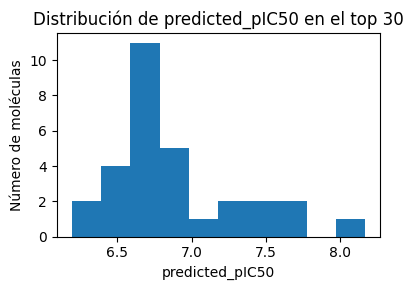

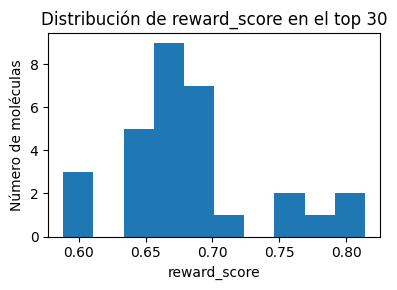

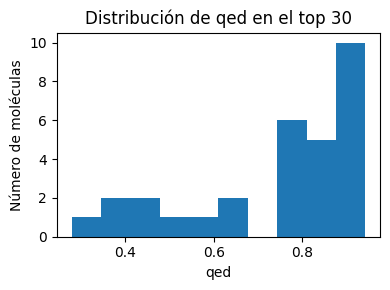

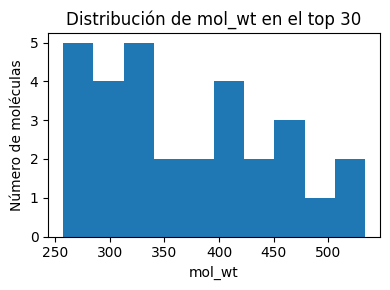

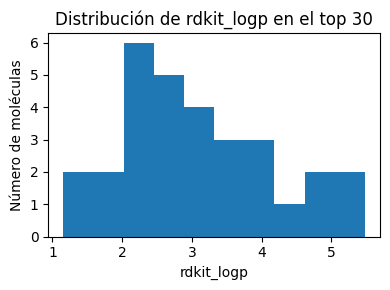

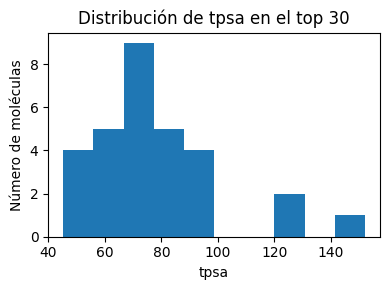

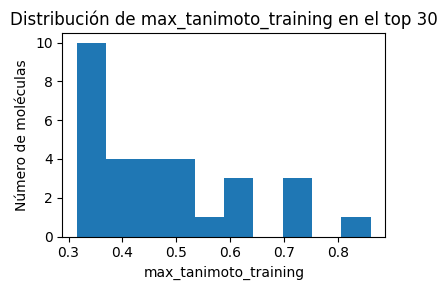

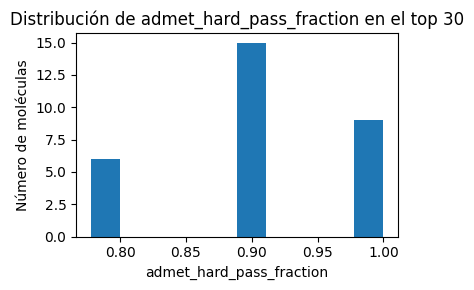

In [19]:
import matplotlib.pyplot as plt

# Variables principales para describir el top 30.
plot_cols = [
    "predicted_pIC50",
    "reward_score",
    "qed",
    "mol_wt",
    "rdkit_logp",
    "tpsa",
    "max_tanimoto_training",
    "admet_hard_pass_fraction",
]

plot_cols = [col for col in plot_cols if col in df_top30.columns]

for col in plot_cols:
    plt.figure(figsize=(4, 3))
    plt.hist(df_top30[col].dropna(), bins=10)
    plt.xlabel(col)
    plt.ylabel("Número de moléculas")
    plt.title(f"Distribución de {col} en el top 30")
    plt.tight_layout()
    plt.show()

### 3.2 Relación entre actividad predicha y novedad estructural

La siguiente representación compara la actividad predicha (`predicted_pIC50`) con la similitud máxima frente al conjunto de entrenamiento (`max_tanimoto_training`).

Esta visualización permite identificar moléculas que combinan buena actividad con cierta novedad estructural. Los puntos con menor similitud al entrenamiento y alta pIC50 son especialmente interesantes, ya que podrían representar estructuras menos redundantes respecto a los datos utilizados para entrenar el modelo.

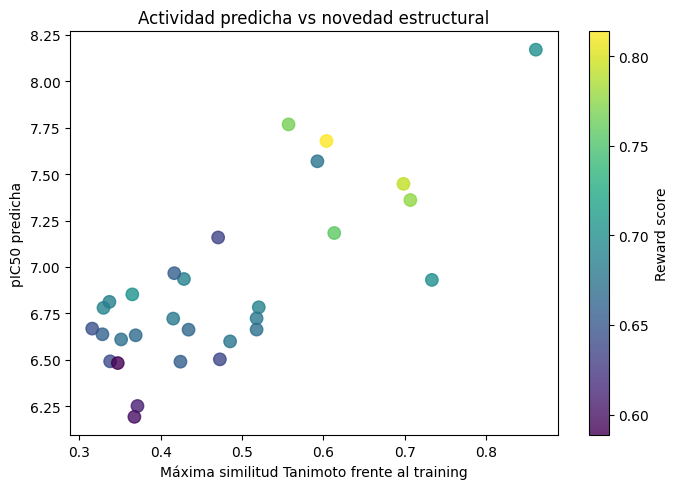

In [20]:
plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    df_top30["max_tanimoto_training"],
    df_top30["predicted_pIC50"],
    s=80,
    alpha=0.8,
    c=df_top30["reward_score"],
)

plt.xlabel("Máxima similitud Tanimoto frente al training")
plt.ylabel("pIC50 predicha")
plt.title("Actividad predicha vs novedad estructural")
plt.colorbar(scatter, label="Reward score")
plt.tight_layout()
plt.show()

### 3.3 Relación entre actividad predicha y perfil ADMET

A continuación se compara la actividad predicha con la fracción de filtros ADMET duros superados. Esta gráfica ayuda a detectar candidatas que combinan potencia estimada y menor riesgo ADMET preliminar.

Las moléculas situadas en la zona superior derecha son las más atractivas desde una perspectiva computacional, ya que presentan alta pIC50 predicha y superan una mayor proporción de filtros ADMET.

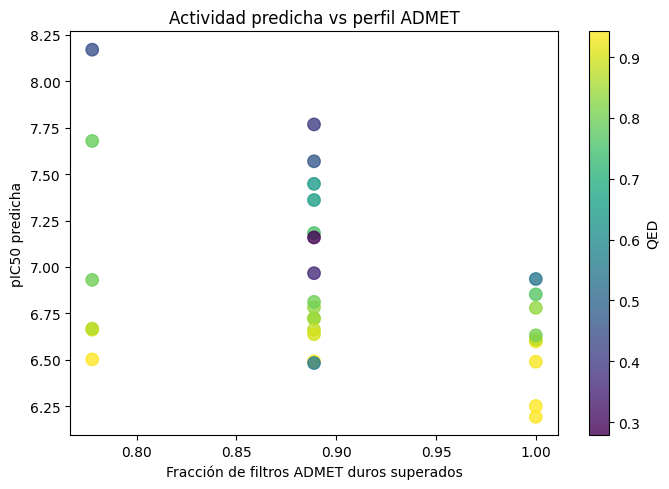

In [21]:
plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    df_top30["admet_hard_pass_fraction"],
    df_top30["predicted_pIC50"],
    s=80,
    alpha=0.8,
    c=df_top30["qed"],
)

plt.xlabel("Fracción de filtros ADMET duros superados")
plt.ylabel("pIC50 predicha")
plt.title("Actividad predicha vs perfil ADMET")
plt.colorbar(scatter, label="QED")
plt.tight_layout()
plt.show()

### 3.4 Comparación del top 10 equilibrado

El top 10 equilibrado se obtuvo a partir de un score interpretable que combina actividad predicha, ADMET, QED, novedad estructural y cumplimiento de reglas básicas. Para comparar visualmente estos candidatos, se genera un mapa de calor con variables normalizadas.

Este tipo de representación permite detectar perfiles complementarios: moléculas más activas, más drug-like, más novedosas o con mejor comportamiento ADMET.

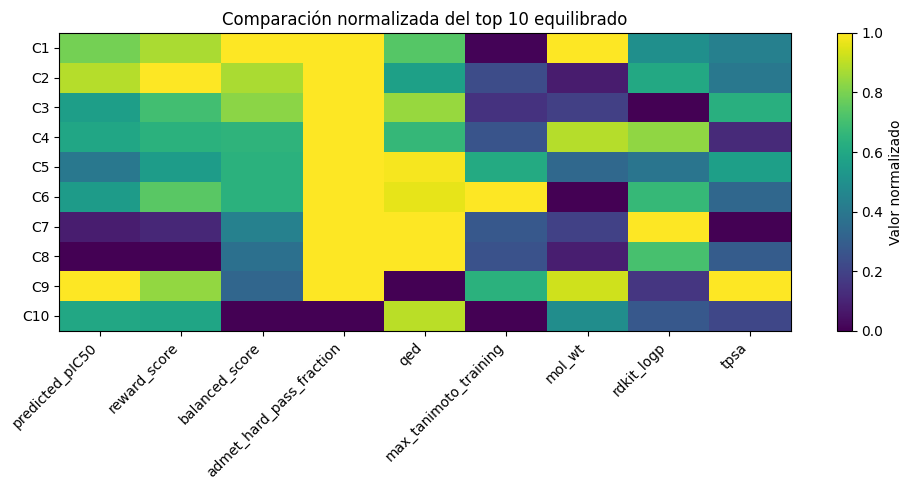

,candidate_id,smiles,predicted_pIC50,balanced_score,reward_score
0,C1,CC(=O)NC1CCN(C(=O)C23CC(CN2c2ncnc4cc(Cl)ccc24)C3)CC1,6.779645,0.717864,0.690375
1,C2,CC(C)n1cnc2ncnc(Nc3cccc(CO)c3)c21,6.852217,0.701126,0.703727
2,C3,NC(=O)c1cc(Nc2cncc(N3CCOCC3)c2)ccn1,6.609368,0.695098,0.671664
3,C4,O=C(Nc1ccc(Br)c(F)c1F)c1cc(N2CCOCC2)ccn1,6.631773,0.672415,0.665329
4,C5,CC(=O)Nc1nc(C(=O)N2CCC(c3ncco3)CC2)cs1,6.489532,0.670683,0.656078
5,C6,CCc1ncnc(Nc2ccc(F)c(C#N)c2)c1OC,6.598890,0.670464,0.676569
6,C7,CN(CC(F)F)C(=O)Nc1ccc2c(Cl)ccnc2c1,6.250883,0.644557,0.609128
7,C8,O=C(Nc1ncc(Oc2ccccc2)cn1)N1CCCC1,6.192257,0.635237,0.597408
8,C9,COc1ccc2c(NC(CO)C(O)c3ccc(S(C)(=O)=O)cc3)ncnc2c1,6.935125,0.630135,0.686361
9,C10,Cc1nc(N(C)CC(C)NC(=O)C2CCN(C)C2)c2ccccc2n1,6.637261,0.587207,0.659769


In [22]:
# Variables utilizadas para comparar visualmente el top 10 equilibrado.
heatmap_cols = [
    "predicted_pIC50",
    "reward_score",
    "balanced_score",
    "admet_hard_pass_fraction",
    "qed",
    "max_tanimoto_training",
    "mol_wt",
    "rdkit_logp",
    "tpsa",
]

heatmap_cols = [col for col in heatmap_cols if col in top_balanced.columns]

# Copia del top 10 equilibrado.
df_heatmap = top_balanced.copy().reset_index(drop=True)

# Etiqueta corta para cada molécula.
df_heatmap["candidate_id"] = [
    f"C{i+1}" for i in range(len(df_heatmap))
]

# Normalización min-max para hacer comparables las variables en el heatmap.
heatmap_data = df_heatmap[heatmap_cols].copy()

for col in heatmap_cols:
    min_val = heatmap_data[col].min()
    max_val = heatmap_data[col].max()
    if max_val != min_val:
        heatmap_data[col] = (heatmap_data[col] - min_val) / (max_val - min_val)
    else:
        heatmap_data[col] = 1.0

plt.figure(figsize=(10, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.xticks(range(len(heatmap_cols)), heatmap_cols, rotation=45, ha="right")
plt.yticks(range(len(df_heatmap)), df_heatmap["candidate_id"])
plt.colorbar(label="Valor normalizado")
plt.title("Comparación normalizada del top 10 equilibrado")
plt.tight_layout()
plt.show()

# Tabla de correspondencia entre ID y SMILES.
df_heatmap[["candidate_id", "smiles", "predicted_pIC50", "balanced_score", "reward_score"]]

### 3.5 Estructuras 2D del top 10 equilibrado

Además de las métricas numéricas, es importante visualizar las estructuras químicas. La representación 2D permite inspeccionar de forma cualitativa la diversidad estructural, la presencia de núcleos comunes y posibles grupos funcionales relevantes.

A continuación se muestran las estructuras del top 10 equilibrado junto con sus principales métricas.

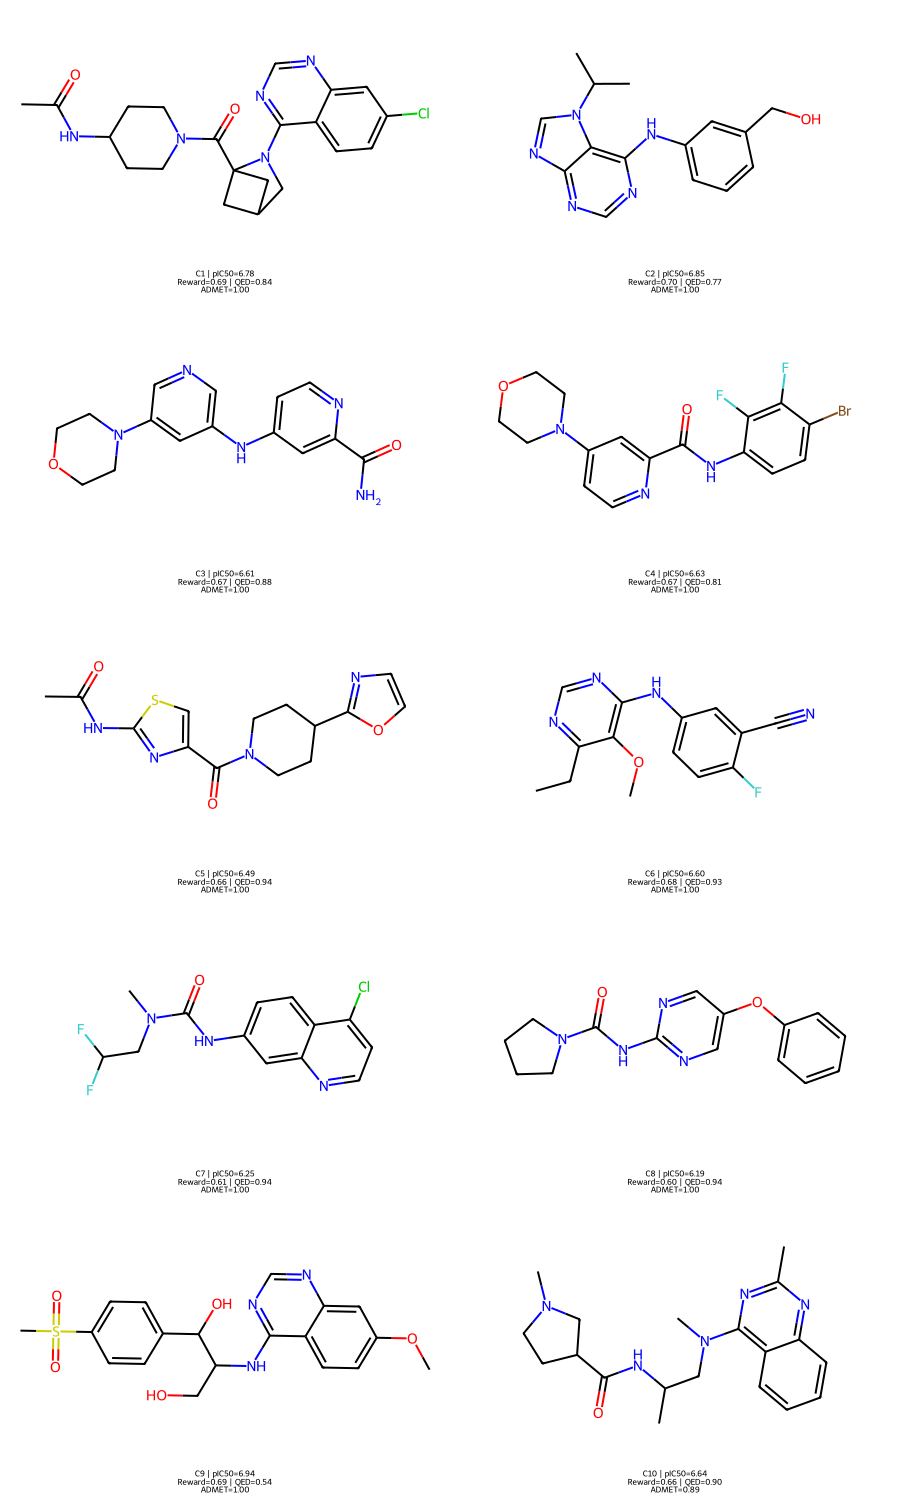

In [23]:
from rdkit import Chem
from rdkit.Chem import Draw

# Construcción de moléculas RDKit para el top 10 equilibrado.
mols_top10 = [
    Chem.MolFromSmiles(smiles)
    for smiles in top_balanced["smiles"]
]

# Leyendas con información compacta para cada molécula.
legends_top10 = []

for i, (_, row) in enumerate(top_balanced.reset_index(drop=True).iterrows(), start=1):
    legend = (
        f"C{i} | pIC50={row['predicted_pIC50']:.2f}\n"
        f"Reward={row['reward_score']:.2f} | QED={row['qed']:.2f}\n"
        f"ADMET={row['admet_hard_pass_fraction']:.2f}"
    )
    legends_top10.append(legend)

img_top10 = Draw.MolsToGridImage(
    mols_top10,
    molsPerRow=2,
    subImgSize=(450, 300),
    legends=legends_top10,
)

img_top10

### 3.6 Estructuras 2D de los perfiles representativos

Los perfiles de candidatos permiten destacar moléculas con fortalezas distintas: mejor score global, mayor actividad predicha, mejor perfil ADMET, mayor novedad estructural, mejor calidad drug-like o mejor equilibrio global.

Esta representación complementa el top 10 equilibrado, ya que ayuda a discutir candidatos que pueden ser relevantes por motivos diferentes.

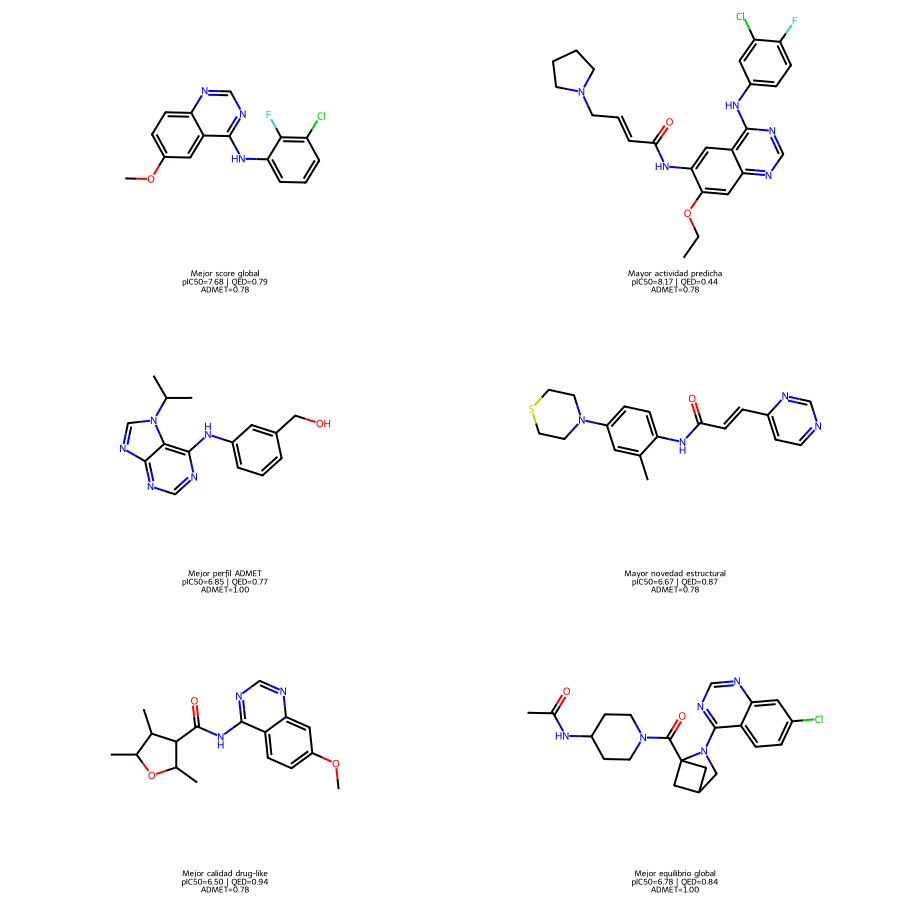

In [24]:
# Construcción de moléculas RDKit para los perfiles únicos.
mols_profiles = [
    Chem.MolFromSmiles(smiles)
    for smiles in df_candidate_profiles_unique["smiles"]
]

# Leyendas compactas con perfil y principales métricas.
legends_profiles = []

for _, row in df_candidate_profiles_unique.iterrows():
    legend = (
        f"{row['profile']}\n"
        f"pIC50={row['predicted_pIC50']:.2f} | QED={row['qed']:.2f}\n"
        f"ADMET={row['admet_hard_pass_fraction']:.2f}"
    )
    legends_profiles.append(legend)

img_profiles = Draw.MolsToGridImage(
    mols_profiles,
    molsPerRow=2,
    subImgSize=(450, 300),
    legends=legends_profiles,
)

img_profiles

### 3.7 Distribución de scaffolds en el top 30

El análisis de scaffolds permite evaluar si el conjunto final está dominado por pocos núcleos estructurales o si existe diversidad química. Una mayor diversidad de scaffolds es deseable porque reduce la dependencia de una única familia molecular y permite proponer diferentes líneas de optimización futura.

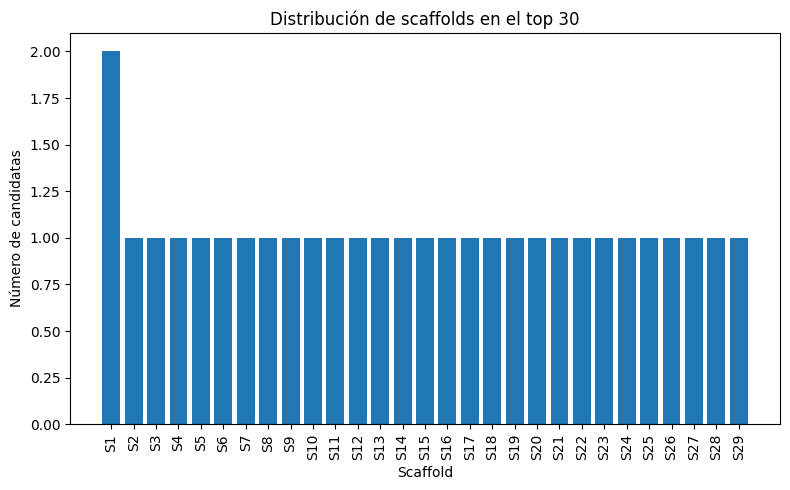

,murcko_scaffold,n_candidates
0,c1ccc(Nc2ncnc3ccccc23)cc1,2
1,O=C(Nc1ccc2ncnc(Nc3ccccc3)c2c1)C1CCOCC1,1
2,c1ccc(Nc2ncnc3ccc(OC4CC5(COC5)C4)cc23)cc1,1
3,O=C(Nc1cc2c(Nc3ccccc3)ncnc2cn1)Nc1nc2n(n1)CCCC2,1
4,c1cnc(Nc2ccc(N3CCOCC3)cc2)nc1,1
5,c1ccc(Nc2ncnc3nc[nH]c23)cc1,1
6,O=C(/C=C/CN1CCCC1)Nc1ccc2ncnc(Nc3ccccc3)c2c1,1
7,O=C(N1CCCCC1)C12CC(CN1c1ncnc3ccccc13)C2,1
8,O=C(Nc1cc(Nc2ccccc2)ncn1)C1CCNCC1,1
9,c1ccc(CCNc2ncnc3ccccc23)cc1,1


In [25]:
# Frecuencia de scaffolds en el top 30.
scaffold_counts = (
    df_top30["murcko_scaffold"]
    .value_counts()
    .reset_index()
)

scaffold_counts.columns = ["murcko_scaffold", "n_candidates"]

plt.figure(figsize=(8, 5))
plt.bar(range(len(scaffold_counts)), scaffold_counts["n_candidates"])
plt.xlabel("Scaffold")
plt.ylabel("Número de candidatas")
plt.title("Distribución de scaffolds en el top 30")
plt.xticks(range(len(scaffold_counts)), [f"S{i+1}" for i in range(len(scaffold_counts))], rotation=90)
plt.tight_layout()
plt.show()

scaffold_counts.head(10)

## 8. Visualización 2D de las candidatas principales

Las estructuras 2D ayudan a comprobar visualmente si las candidatas seleccionadas son razonables, si existen familias químicas repetidas y si aparecen motivos estructurales similares a inhibidores conocidos.

Esta visualización requiere RDKit. Si RDKit no está instalado en el entorno, la celda mostrará un aviso y el resto del notebook podrá ejecutarse igualmente.


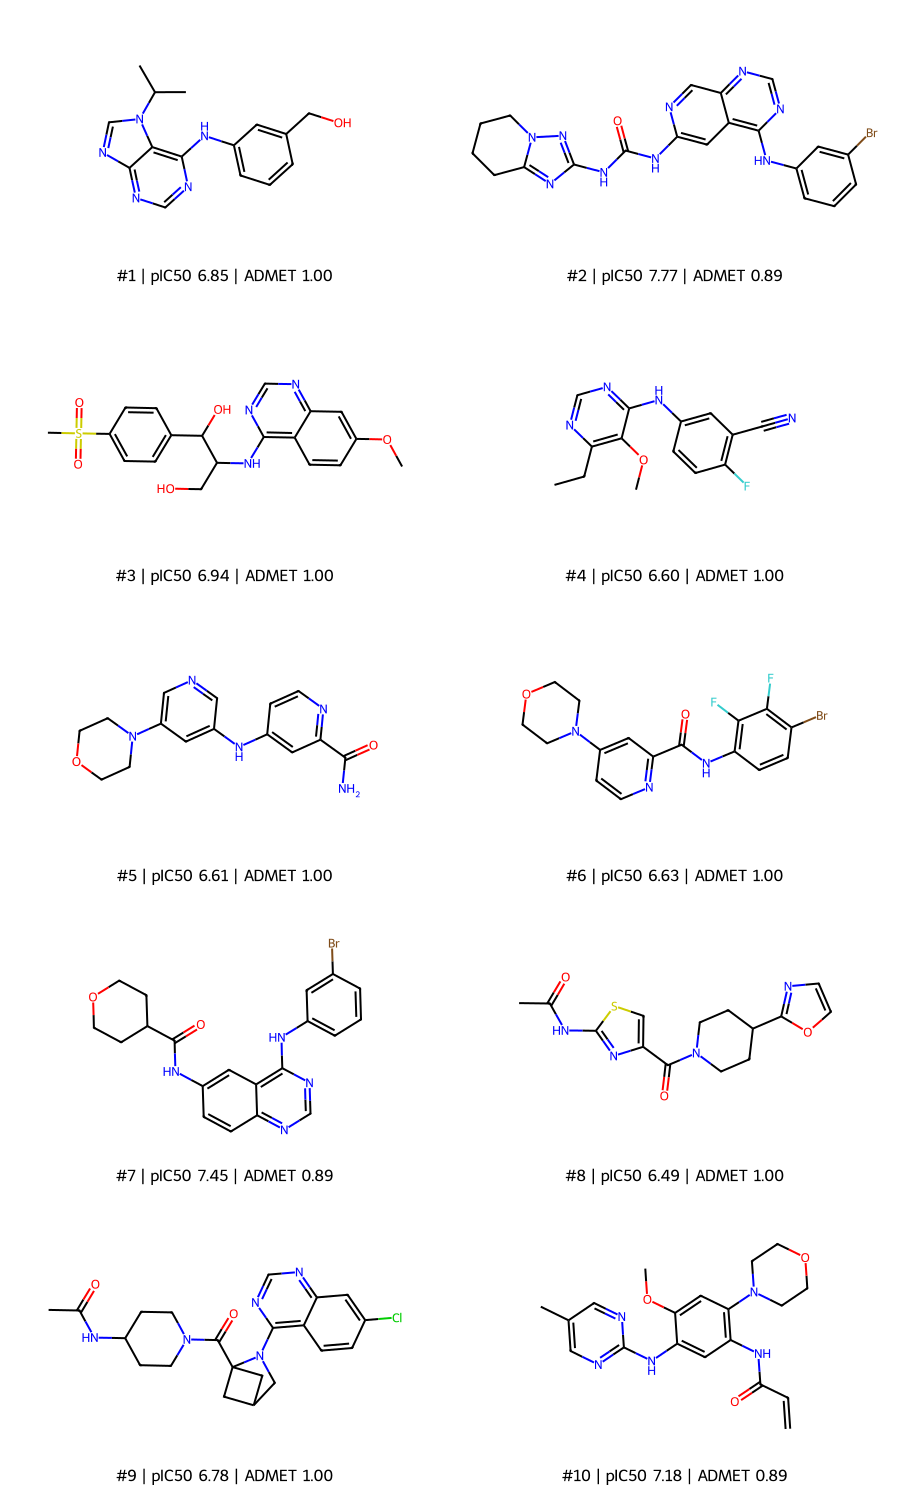

In [19]:
try:
    from rdkit import Chem
    from rdkit.Chem import Draw
    RDKIT_AVAILABLE = True
except Exception as e:
    RDKIT_AVAILABLE = False
    print("RDKit no está disponible en este entorno:", e)

if RDKIT_AVAILABLE:
    mols = []
    legends = []

    for _, row in top10.iterrows():
        smi = row.get("smiles", None)
        mol = Chem.MolFromSmiles(smi) if isinstance(smi, str) else None
        if mol is not None:
            mols.append(mol)
            legends.append(
                f"#{int(row.get('memory_rank', 0))} | pIC50 {row.get('predicted_pIC50', np.nan):.2f} | ADMET {row.get('admet_hard_pass_fraction', np.nan):.2f}"
            )

    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=2,
        subImgSize=(450, 300),
        legends=legends,
        useSVG=True,
    )
    display(img)
else:
    display(Markdown("**No se generaron estructuras 2D porque RDKit no está instalado.**"))


### 3.6 Estructuras 2D de los perfiles representativos

Los perfiles de candidatos permiten destacar moléculas con fortalezas distintas: mejor score global, mayor actividad predicha, mejor perfil ADMET, mayor novedad estructural, mejor calidad drug-like o mejor equilibrio global.

Esta representación complementa el top 10 equilibrado, ya que ayuda a discutir candidatos que pueden ser relevantes por motivos diferentes.

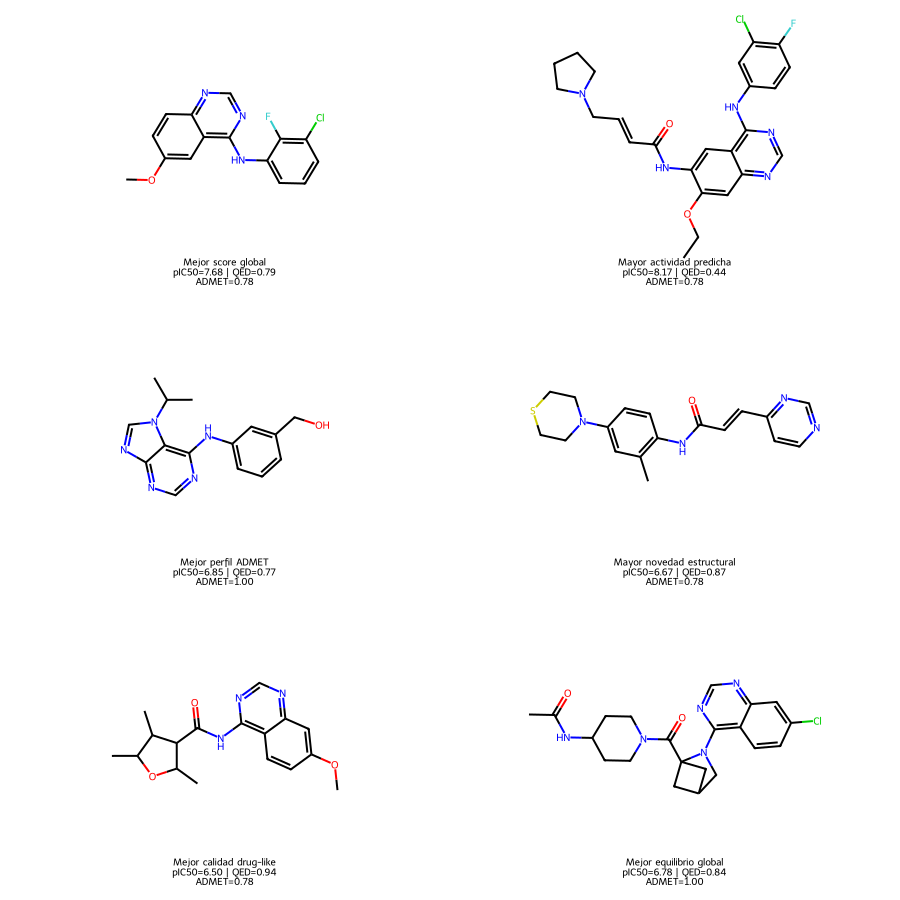

In [53]:
# Construcción de moléculas RDKit para los perfiles únicos.
mols_profiles = [
    Chem.MolFromSmiles(smiles)
    for smiles in df_candidate_profiles_unique["smiles"]
]

# Leyendas compactas con perfil y principales métricas.
legends_profiles = []

for _, row in df_candidate_profiles_unique.iterrows():
    legend = (
        f"{row['profile']}\n"
        f"pIC50={row['predicted_pIC50']:.2f} | QED={row['qed']:.2f}\n"
        f"ADMET={row['admet_hard_pass_fraction']:.2f}"
    )
    legends_profiles.append(legend)

img_profiles = Draw.MolsToGridImage(
    mols_profiles,
    molsPerRow=2,
    subImgSize=(450, 300),
    legends=legends_profiles,
)

img_profiles

## 9. Análisis de scaffolds

El scaffold de Murcko resume el núcleo estructural de una molécula. En el contexto de este TFM, sirve para responder a una pregunta crítica:

> ¿El top 30 contiene diversidad química real o muchas variantes de la misma familia estructural?

Esto es importante porque un top 30 muy concentrado en pocos scaffolds puede parecer fuerte por score, pero ser débil como propuesta exploratoria. En cambio, una selección con varios scaffolds ofrece más alternativas para validación posterior.


## 11. Relación entre actividad, ADMET y novedad

Una buena candidata no es necesariamente la que maximiza una sola variable. En descubrimiento temprano de fármacos, suelen existir compromisos entre actividad, toxicidad, absorción y novedad estructural.

Los siguientes gráficos permiten visualizar esos compromisos dentro del top 30.


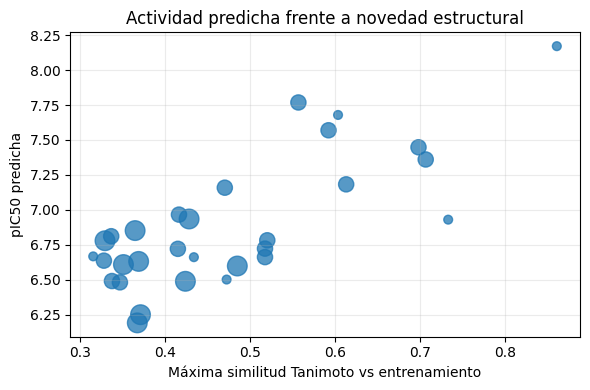

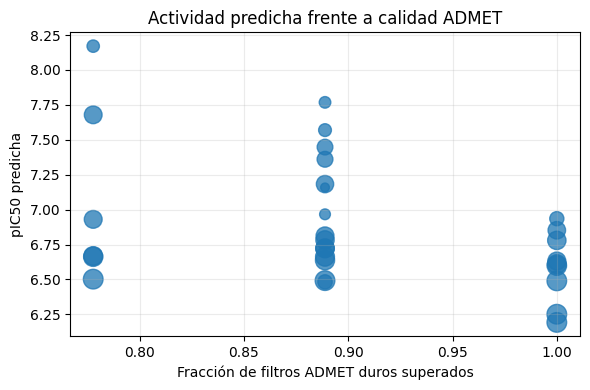

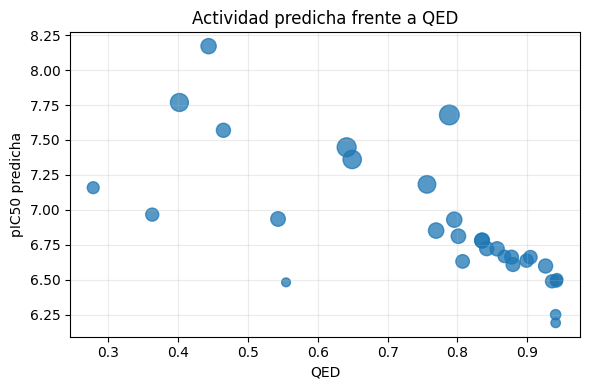

In [25]:
def scatter_if_available(df, x, y, size_col=None, title=None, xlabel=None, ylabel=None):
    if x not in df.columns or y not in df.columns:
        print(f"No se puede graficar {x} vs {y}: faltan columnas.")
        return

    plt.figure(figsize=(6, 4))
    if size_col and size_col in df.columns:
        sizes = 40 + 160 * minmax_score(df[size_col], True)
    else:
        sizes = 80
    plt.scatter(df[x], df[y], s=sizes, alpha=0.75)
    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    plt.title(title or f"{y} vs {x}")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

scatter_if_available(
    shortlist,
    x="max_tanimoto_training",
    y="predicted_pIC50",
    size_col="admet_hard_pass_fraction",
    title="Actividad predicha frente a novedad estructural",
    xlabel="Máxima similitud Tanimoto vs entrenamiento",
    ylabel="pIC50 predicha",
)

scatter_if_available(
    shortlist,
    x="admet_hard_pass_fraction",
    y="predicted_pIC50",
    size_col="qed",
    title="Actividad predicha frente a calidad ADMET",
    xlabel="Fracción de filtros ADMET duros superados",
    ylabel="pIC50 predicha",
)

scatter_if_available(
    shortlist,
    x="qed",
    y="predicted_pIC50",
    size_col="reward_score",
    title="Actividad predicha frente a QED",
    xlabel="QED",
    ylabel="pIC50 predicha",
)


## 12. Candidatas con posibles riesgos

Esta sección identifica moléculas que conviene tratar con cautela en la memoria. No significa que deban descartarse automáticamente, pero sí que no deberían presentarse como candidatas perfectas.

Se revisan especialmente:

- moléculas con fallos ADMET;
- moléculas muy similares al conjunto de entrenamiento;
- moléculas con QED bajo;
- moléculas con varias violaciones de Lipinski.


In [26]:
risk_flags = shortlist.copy()

if "n_failed_admet_rules" in risk_flags.columns:
    risk_flags["risk_admet_failure"] = risk_flags["n_failed_admet_rules"] > 0
else:
    risk_flags["risk_admet_failure"] = False

if "max_tanimoto_training" in risk_flags.columns:
    risk_flags["risk_near_training_copy"] = risk_flags["max_tanimoto_training"] >= 0.85
else:
    risk_flags["risk_near_training_copy"] = False

if "qed" in risk_flags.columns:
    risk_flags["risk_low_qed"] = risk_flags["qed"] < 0.35
else:
    risk_flags["risk_low_qed"] = False

if "ro5_violations" in risk_flags.columns:
    risk_flags["risk_ro5"] = risk_flags["ro5_violations"] > 1
else:
    risk_flags["risk_ro5"] = False

risk_flags["n_risk_flags"] = risk_flags[[
    "risk_admet_failure", "risk_near_training_copy", "risk_low_qed", "risk_ro5"
]].sum(axis=1)

risk_cols = [
    "rank", "smiles", "predicted_pIC50", "reward_score", "n_risk_flags",
    "risk_admet_failure", "failed_admet_rules",
    "risk_near_training_copy", "max_tanimoto_training",
    "risk_low_qed", "qed", "risk_ro5", "ro5_violations"
]
risk_cols = [c for c in risk_cols if c in risk_flags.columns]

display(risk_flags.sort_values(["n_risk_flags", "reward_score"], ascending=[False, False])[risk_cols].head(15))


,smiles,predicted_pIC50,reward_score,n_risk_flags,risk_admet_failure,risk_near_training_copy,max_tanimoto_training,risk_low_qed,qed,risk_ro5,ro5_violations
6,CCOc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1NC(=O)/C=C/CN1CCCC1,8.170641,0.701087,1,False,True,0.861111,False,0.443757,False,1
15,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC1CN(C(=O)OC(C)(C)C)CC1F,7.569358,0.676497,1,False,False,0.592593,False,0.465007,True,2
26,COc1cc2ncnc(NC(c3ccccc3)c3cnccn3)c2cc1NC(=O)c1cc2c(nc1O)CCC2=O,7.158876,0.634842,1,False,False,0.470588,True,0.278576,False,1
0,COc1ccc2ncnc(Nc3cccc(Cl)c3F)c2c1,7.678820,0.813901,0,False,False,0.603774,False,0.788442,False,0
1,O=C(Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1)C1CCOCC1,7.447770,0.792513,0,False,False,0.698413,False,0.641418,False,0
2,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC1CC2(COC2)C1,7.360564,0.776262,0,False,False,0.706897,False,0.649353,False,0
3,O=C(Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1)Nc1nc2n(n1)CCCC2,7.768092,0.767045,0,False,False,0.557143,False,0.401990,False,0
4,C=CC(=O)Nc1cc(Nc2ncc(C)cn2)c(OC)cc1N1CCOCC1,7.182763,0.756761,0,False,False,0.613333,False,0.756415,False,0
5,CC(C)n1cnc2ncnc(Nc3cccc(CO)c3)c21,6.852217,0.703727,0,False,False,0.365079,False,0.769510,False,0
7,COc1cc2ncnc(Nc3cc(F)ccc3F)c2cc1OC,6.930272,0.701011,0,False,False,0.733333,False,0.795479,False,0


In [27]:
n_with_risks = int((risk_flags["n_risk_flags"] > 0).sum())
n_without_risks = int((risk_flags["n_risk_flags"] == 0).sum())

risk_comment = f"""
### Comentario sobre riesgos

De las 30 candidatas finales, **{n_without_risks}** no presentan ninguna de las alertas de riesgo definidas en esta revisión secundaria, mientras que **{n_with_risks}** presentan al menos una.

Este análisis es útil para no caer en una conclusión ingenua. Una molécula puede estar bien posicionada por score, pero si presenta alertas ADMET, baja calidad farmacológica o similitud excesiva con el entrenamiento, debe discutirse con cautela.

Para la memoria, las candidatas sin alertas son las mejores para destacar como propuestas principales. Las candidatas con alertas pueden mencionarse como moléculas potentes pero con limitaciones.
"""

display(Markdown(risk_comment))



### Comentario sobre riesgos

De las 30 candidatas finales, **27** no presentan ninguna de las alertas de riesgo definidas en esta revisión secundaria, mientras que **3** presentan al menos una.

Este análisis es útil para no caer en una conclusión ingenua. Una molécula puede estar bien posicionada por score, pero si presenta alertas ADMET, baja calidad farmacológica o similitud excesiva con el entrenamiento, debe discutirse con cautela.

Para la memoria, las candidatas sin alertas son las mejores para destacar como propuestas principales. Las candidatas con alertas pueden mencionarse como moléculas potentes pero con limitaciones.


## 13. Comparación con el conjunto top100 y Pareto

El top 30 debería ser una selección coherente del espacio Pareto/top100, no una muestra arbitraria. Si existen los archivos `top100` y `pareto`, se comparan sus distribuciones con el top 30.


In [28]:
def compare_distribution(datasets: dict, col: str):
    rows = []
    for name, data in datasets.items():
        if data is not None and col in data.columns:
            rows.append({
                "dataset": name,
                "count": len(data),
                "mean": data[col].mean(),
                "median": data[col].median(),
                "min": data[col].min(),
                "max": data[col].max(),
            })
    return pd.DataFrame(rows)

datasets = {
    "shortlist30": shortlist,
    "top100": top100,
    "pareto": pareto,
    "eligible": eligible,
}

for col in ["predicted_pIC50", "admet_hard_pass_fraction", "max_tanimoto_training", "qed", "reward_score"]:
    comp = compare_distribution(datasets, col)
    if not comp.empty:
        display(Markdown(f"#### Comparación de `{col}`"))
        display(comp.round(3))


#### Comparación de `predicted_pIC50`

,dataset,count,mean,median,min,max
0,shortlist30,30,6.891,6.751,6.192,8.171
1,top100,37,6.807,6.722,6.098,8.171
2,pareto,37,6.807,6.722,6.098,8.171
3,eligible,2133,6.386,6.309,6.000,8.171


#### Comparación de `admet_hard_pass_fraction`

,dataset,count,mean,median,min,max
0,shortlist30,30,0.900,0.889,0.778,1.0
1,top100,37,0.886,0.889,0.778,1.0
2,pareto,37,0.886,0.889,0.778,1.0
3,eligible,2133,0.869,0.889,0.778,1.0


#### Comparación de `max_tanimoto_training`

,dataset,count,mean,median,min,max
0,shortlist30,30,0.476,0.431,0.316,0.861
1,top100,37,0.456,0.417,0.309,0.861
2,pareto,37,0.456,0.417,0.309,0.861
3,eligible,2133,0.380,0.347,0.300,0.929


#### Comparación de `qed`

,dataset,count,mean,median,min,max
0,shortlist30,30,0.749,0.821,0.279,0.942
1,top100,37,0.708,0.801,0.279,0.946
2,pareto,37,0.708,0.801,0.279,0.946
3,eligible,2133,0.603,0.611,0.251,0.946


#### Comparación de `reward_score`

,dataset,count,mean,median,min,max
0,shortlist30,30,0.682,0.677,0.588,0.814
1,top100,37,0.652,0.665,0.408,0.814
2,pareto,37,0.652,0.665,0.408,0.814
3,eligible,2133,0.551,0.547,0.343,0.814


## 14. Figuras recomendadas para la memoria

A partir de este análisis, las figuras más útiles para la memoria serían:

1. **Grid 2D del top 10** con pIC50 y ADMET en la leyenda.  
   Sirve para mostrar visualmente las moléculas priorizadas.

2. **Scatter pIC50 vs similitud al entrenamiento**, con tamaño o color según ADMET.  
   Sirve para explicar el equilibrio entre potencia y novedad.

3. **Barplot de scaffolds principales del top 30**.  
   Sirve para discutir diversidad estructural y redundancia química.

4. **Tabla de perfiles del top 10**.  
   Debe incluir pIC50, ADMET, fallos ADMET, Tanimoto al entrenamiento, QED, RO5 y scaffold.

5. **Tabla de riesgos**.  
   Útil para demostrar pensamiento crítico: no todas las moléculas priorizadas son igual de defendibles.


## 15. Conclusión final

El notebook 03 permitió pasar de un conjunto amplio de moléculas generadas a una shortlist final de 30 candidatas priorizadas mediante criterios de actividad predicha, propiedades ADMET, similitud estructural, drug-likeness y análisis multiobjetivo.

El análisis realizado en este notebook muestra que la selección final debe interpretarse como una priorización computacional temprana, no como una validación experimental. Aun así, el top 30 ofrece un conjunto manejable de moléculas con perfiles prometedores para discusión posterior.

La principal conclusión es que las mejores candidatas no son necesariamente las que maximizan únicamente la pIC50 predicha. Las opciones más defendibles son aquellas que combinan:

- actividad estimada alta frente a EGFR;
- ausencia o bajo número de alertas ADMET;
- similitud moderada frente al entrenamiento, evitando copias;
- propiedades fisicoquímicas compatibles con moléculas tipo fármaco;
- diversidad de scaffolds suficiente para no depender de una única familia química.

Para la memoria, se recomienda presentar el **top 10 principal** junto con un **top 10 diversificado por scaffold**. Esta doble perspectiva permite discutir tanto las moléculas más prometedoras por score como la diversidad química disponible para futuras etapas de validación.
